In [80]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [81]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [82]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [97]:
block_size = 3  # how mach characters should be considered for the next one

def build_dataset(words):
    X , Y = [] , []
    for word in words:
        context = [0]*block_size
        for ch in word + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
        
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print(Xtr,Xtr.shape)

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])
tensor([[ 0,  0,  0],
        [ 0,  0, 20],
        [ 0, 20,  1],
        ...,
        [25,  5, 14],
        [ 5, 14, 14],
        [14, 14,  1]]) torch.Size([182437, 3])


In [103]:
g = torch.Generator().manual_seed(2147483647) 
#  embedding tensor is somoething that stores the what is the output for the previous set of examples like a N in the bigram
C = torch.randn((27,10),generator=g) # (27,10) because there are the 26 alphabets and one '.' total 27 characters each thing is represented in the 10 dimensional vector.
W1 = torch.randn((30,200),generator=g) 
b1 = torch.randn(200,generator=g)           
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

In [104]:
for parameter in parameters:
    parameter.requires_grad = True

In [105]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [106]:
lri = []
lossi = []
stepi = []

In [107]:
# gradient descent

for i in range(200000):
    
    ix = torch.randint(0,Xtr.shape[0],(32,))
    # Xtr[ix] = [1,18,0] just because of this ['a','r','.']
    emb = C[Xtr[ix]]  
    # after this C[Xtr[ix]] means each index is converted to 10 dimensional so it will be (3,10)
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    # now that emb is flatten to the (1,30) they mean 3*10 = 30 because neural network expects one vecgtor
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
        
    stepi.append(i)
    lossi.append(loss.log10().item())
    

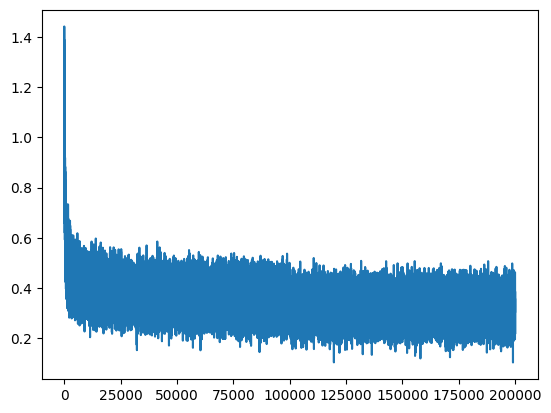

In [108]:
plt.plot(stepi, lossi)

In [109]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1335, grad_fn=<NllLossBackward0>)

In [110]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1922, grad_fn=<NllLossBackward0>)

In [111]:
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1792, grad_fn=<NllLossBackward0>)

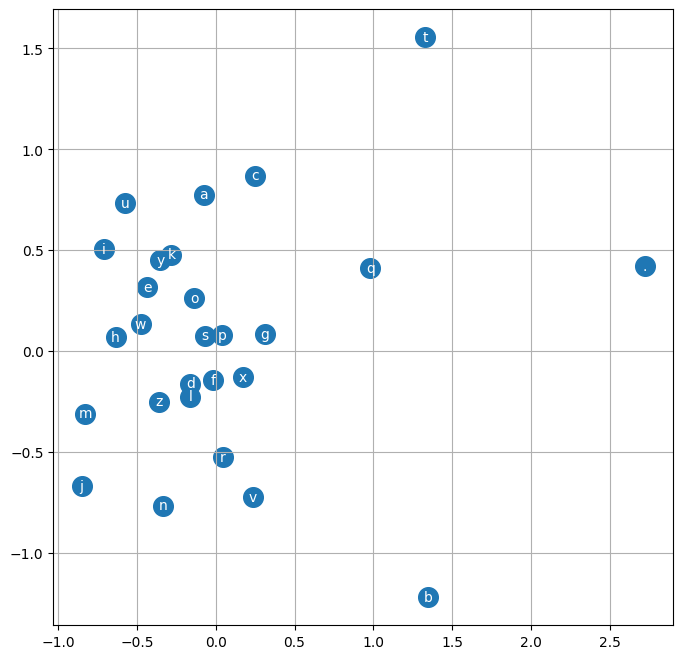

In [112]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [113]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size 
    while True:
        emb = C[torch.tensor([context])] 
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carpaveqhille.
khi.
mri.
revty.
ska.
sane.
mahne.
faveryncitheei.
nellara.
chaiir.
kaleigh.
ham.
pora.
quinn.
sulivea.
jadii.
wakelo.
dearyxi.
jace.
pirra.
